## Hospital Performance And Efficiancy Analysis
#### This project analyze hospital Performance using multiple healthcare dataset. The goal is to clean, prepare and analyze hospital data to understand the relationship between hospital ratings, medicare spending, and patient outcomes.

In [ ]:
# Importing necessary libraries to load, process, analyze and visualize the dataset.
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Loading hospital general information dataset
hospital_info = pd.read_csv("../data/Hospital_General_Information.csv")
hospital_info.head(5)

## Exploring the Hospital Info Dataset
The structure and contents of the dataset are examined to understand data types, check for missing values, and get the overview of the dataset.

In [ ]:
# checking datatypes 
hospital_info.info()

In [ ]:
# checking number of rows and columns
hospital_info.shape

## Data Cleaning: Hospital Info Data
#### In this section, hospital general information dataset is cleaned to prepare it for analysis. the cleaning process includes :
* Reviewing columns names
* Removing unnecessary columns
* Renaming columns 
* Checking for missing values
#### The goal is to create a clean dataset that can be easily used for analysis and combined with other datasets.


#### Inspecting columns

In [ ]:
# Inspecting Columns
hospital_info.columns

#### Removing Unnecessary Columns

In [ ]:
# Removing the unnecessary columns from hospital data to make dataset cleaner and easier to work during analysis.
hospital_info = hospital_info.drop(columns=['Address', 'City/Town',
       'ZIP Code', 'County/Parish', 'Telephone Number',
       'Meets criteria for birthing friendly designation',
        'Hospital overall rating footnote',
       'MORT Group Measure Count', 'Count of Facility MORT Measures',
       'Count of MORT Measures Better', 'Count of MORT Measures No Different',
       'Count of MORT Measures Worse', 'MORT Group Footnote',
       'Safety Group Measure Count', 'Count of Facility Safety Measures',
       'Count of Safety Measures Better',
       'Count of Safety Measures No Different',
       'Count of Safety Measures Worse', 'Safety Group Footnote',
       'READM Group Measure Count', 'Count of Facility READM Measures',
       'Count of READM Measures Better',
       'Count of READM Measures No Different', 'Count of READM Measures Worse',
       'READM Group Footnote', 'Pt Exp Group Measure Count',
       'Count of Facility Pt Exp Measures', 'Pt Exp Group Footnote',
       'TE Group Measure Count', 'Count of Facility TE Measures',
       'TE Group Footnote'], axis=1)
hospital_info.head(5)

#### Renaing Columns
##### In this step, A function was created to rename columns.The original dataset contains spaces and special character, which can cause error during analysis. columns are renamed using snake_case formatting.

In [ ]:
# column naming function
def rename_columns(df, new_names):
    return df.rename(columns=new_names)

In [ ]:
hospital_info= rename_columns(hospital_info,{
    'Facility ID' : 'facility_id',
    'Facility Name' : 'facility_name',
    'State': 'state',
    'Hospital Type' : 'hospital_type',
    'Hospital Ownership' : 'hospital_ownership',
    'Emergency Services' : 'emergency_services',
    'Hospital overall rating' : 'hospital_overall_rating'
    
})

#### Checking for missing values
##### The dataset is examined for missing(Null) values. Identifying missing data is important because it can affect analysis accuracy.

In [ ]:
# checking null values
hospital_info.isnull().sum()

In [ ]:
# Information about the dataset
hospital_info.info()

#### Checking for Duplicates
In this step, dataset is checked for duplicate rows. Duplicate rows can cause error and may lead to double counting hospital data. Duplicate rows will be identified and removed.

In [ ]:
#check duplicates based on facility_id
duplicates_id = hospital_info.duplicated(subset=['facility_id']).sum()
duplicates_id 

##### Each hospital is uniquely represented in the dataset.

In [ ]:
# hospital-info dataset overview
hospital_info.describe()

#### Replacing 'Not Available' to Nan

In [ ]:
# some rows in hospital_overall_rating column are 'Not Available'. I'm replacing that to NaN values and chenging datatype object to numeric.
hospital_info['hospital_overall_rating'] = pd.to_numeric(hospital_info['hospital_overall_rating'].replace('Not Available', np.nan))



In [ ]:
# List of unique states in hospital dataset
hospital_info['state'].unique()

##### Hospital_info dataset includes 56 unique states, which include 50 US states plus district of columnia(DC), and US territories : PR(PPuerto Rico), VI (Virgin Islands), AS (American Samoa), GU (Guam), MP (Northern Mariana Islands)

In [ ]:
# Loading medicare hospital spending per patient dataset
medicare_data = pd.read_csv("../data/Medicare_Hospital_spending_Per_Patient-Hospital.csv")
medicare_data.head(10)

In [ ]:
# checking datatypes and missing values
medicare_data.info()

In [ ]:
# total rows and columns
medicare_data.shape

### Data Cleaning: Medicare Info Data
#### In this section, medicare spending information dataset is cleaned to prepare it for analysis. the cleaning process includes :
* Reviewing columns names
* Inspecting null values
* Removing unnecessary columns
* Renaming columns 
* Checking for missing values

In [ ]:
# columns in medicare dataset
medicare_data.columns

In [ ]:
# finding null values
medicare_data.isnull().sum()

#### Removing unnecessery columns

In [ ]:
# Removing unnecessery columns from medicare data
medicare_data = medicare_data.drop(columns=['Address', 'City/Town', 
       'ZIP Code', 'Facility Name', 'State','County/Parish','Measure ID', 'Telephone Number', 'Footnote'])
medicare_data.head(10)

In [ ]:
# some rows in Score column are 'Not Available". I'm replacing this to NaN, this allows numeric analysis.
medicare_data['Score']= medicare_data['Score'].replace('Not Available', np.nan)

# checking for the number of hospitals didn't report spending score
medicare_data['Score'].isna().sum()

##### out of 4627 hospitals in the dataset, 1728 do not have reported spending score, These missing values replaced with NaN to allow proper numeric analysis.

#### Renaming columns

In [ ]:
#renaming using previously created function
medicare_data = rename_columns(medicare_data, {
   'Facility ID' : 'facility_id',
    'Measure Name' : 'measure_name',
    'Score' : 'spending_score',
    'Start Date' : 'start_date',
    'End Date' : 'end_date'
})

#### Inspecting duplicates

In [ ]:
# checking duplicate rows
medicare_data.duplicated(subset=['facility_id']).sum()

In [ ]:
# checking the data types
medicare_data.dtypes

#### Data type conversion and custom Function:
* Numeric datatype to object
* Function to convert object to numeric
* Function to convert object to datetime


In [ ]:
# converting the facility_id to string as IDs are identifiers not numbers.
medicare_data['facility_id'] = medicare_data['facility_id'].astype(str)


In [ ]:
# Function to convert object to numeric datatype
def convert_to_numeric(df, columns):
    for column in columns:
        df[column]=pd.to_numeric(df[column])
    return df

# converting spending score to numeric datatype.
medicare_data = convert_to_numeric(medicare_data, ['spending_score'])

In [ ]:
# Function to convert string date to datetime datatype.
def convert_to_datetime(df,columns):
    for column in columns:
        df[column] = pd.to_datetime(df[column])
    return df

#converting start_date and end_date to datetime
medicare_data= convert_to_datetime(medicare_data,['start_date', 'end_date'])

In [ ]:
# overview of medicare_data after cleaning dataset
medicare_data['spending_score'].describe()


In [ ]:
# Loading unplanned hospital visits
unplanned_visit_data= pd.read_csv("../data/Unplanned_Hospital_visits-Hospital.csv")
unplanned_visit_data.head(5)

# The unplanned visit dataset contains the information about hospital visits or return visits for different medical conditions.

In [ ]:
unplanned_visit_data.dtypes

In [ ]:
# Unplanned  visit rows and columns
unplanned_visit_data.shape

#### Data cleaning

In [ ]:
# checking for null values
unplanned_visit_data.isnull().sum()

In [ ]:
#columns in unplanned visit data
unplanned_visit_data.columns

In [ ]:
# removing unnecessery columns from unplanned visit data
unplanned_visit_data = unplanned_visit_data.drop(columns=['Address', 'City/Town',
       'ZIP Code', 'County/Parish', 'Telephone Number', 'Measure ID',
         'Denominator', 'Facility Name',	'State',
       'Lower Estimate', 'Higher Estimate', 
        'Footnote'])
unplanned_visit_data.head(5)

In [ ]:
# some rows in Number of Patients and Number of Patients Returned_returned columns have 'Not Applicable. I'm replacing this to NaN, this allows numeric analysis.
unplanned_visit_data['Number of Patients'] = unplanned_visit_data['Number of Patients'].replace('Not Applicable', np.nan)
unplanned_visit_data['Number of Patients Returned']= unplanned_visit_data['Number of Patients Returned'].replace('Not Applicable', np.nan)

# some rows in Score, number of patients and number of patients columns have 'Not Available'. replacing this to NaN.
unplanned_visit_data[['Score', 'Number of Patients', 'Number of Patients Returned']] = unplanned_visit_data[['Score', 'Number of Patients', 'Number of Patients Returned']].replace('Not Available', np.nan)

In [ ]:
# renaming columns cleanly
unplanned_visit_data = rename_columns(unplanned_visit_data, {
    'Facility ID' : 'facility_id',
    'Measure Name' : 'measure_name',
    'Compared to National' : 'compared_to_national',
    'Score' : 'visit_score',
    'Number of Patients': 'num_patients',
    'Number of Patients Returned': 'num_patient_returned',
    'Start Date': 'start_date',
    'End Date' : 'end_date'
})
unplanned_visit_data.head(5)


In [ ]:
# checking duplicate rows
unplanned_visit_data.duplicated().sum()

In [ ]:
unplanned_visit_data.dtypes

In [ ]:
#converting start_date and end_date to datetime calling function

unplanned_visit_data= convert_to_datetime(unplanned_visit_data,['start_date', 'end_date'])

#converting visit_score, num_patients, and num_patients returns from string to numeric data type calling function
unplanned_visit_data = convert_to_numeric(unplanned_visit_data,['visit_score','num_patients','num_patient_returned'])

In [ ]:
# Summary statics for unplanned visit data
unplanned_visit_data.describe()

In [ ]:
# unique measure name in unplanned visit dataset
unplanned_visit_data['measure_name'].unique()

In [ ]:
# Average visit score grouped by measure name
unplanned_visit_data.groupby('measure_name')['visit_score'].mean().sort_values(ascending=False).round(2)

#### Connect to SQLite Database
##### In this step I'm creating a connection to SQLite database. where all the cleaned datasets will be stored.

In [ ]:
# Creating connection
connection = sqlite3.connect("../data/hospital_performance.db")
cursor = connection.cursor()

# Loading Cleaned datasets into SQL database as seperate tables.
hospital_info.to_sql('hospital_info', connection, if_exists='replace', index=False)
medicare_data.to_sql('medicare_spending', connection, if_exists='replace', index=False)
unplanned_visit_data.to_sql('unplanned_visits', connection, if_exists='replace', index=False)


In [ ]:
# varifying the tables to confirm the database is successfully created.
pd.read_sql("SELECT * FROM hospital_info", connection)
pd.read_sql("SELECT * FROM medicare_spending", connection)
pd.read_sql("SELECT * FROM unplanned_visits ", connection)



### SQL quaries
##### I'm using sql quaries to explore relationships between hospital charasteristic, Medicare spending and patients visits. The goal of this analysis is to investigate patterns in hospital performance and efficency.
##### The following questions guide the analysis:
* Do hospital with higher rating spend more or less on Medicare service?
* Which States have the highest rating hospitals?
* Top 10 Hospitals with high medicare spending and high quality
* Which hospital have the higher rates of unplanned patient return?
* Is there a relationship between number of patients visits and no of patient returns?
* Do hospitals that provide Imergency services have different performace rating?



#### Query: 1. Do hospitals with higher rating spend more or less on Medicare service?

In [177]:
query1 = ''' select
    h.hospital_overall_rating,
    avg(m.spending_score) as avg_spending
from hospital_info h
join medicare_spending m
    on h.facility_id = m.facility_id
group by h.hospital_overall_rating
order by h.hospital_overall_rating;
'''
result1 = pd.read_sql(query1, connection)
result1

,hospital_overall_rating,avg_spending
0,NaN,0.974392
1,1.0,1.027952
2,2.0,1.006339
3,3.0,0.994707
4,4.0,0.978430
5,5.0,0.969886


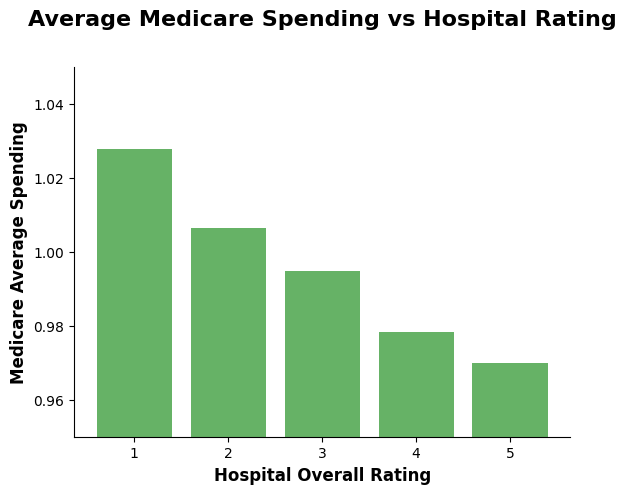

In [178]:
# bar chart to visulize relation between hospital overall rating and average spending

# remove hospital with no rating for better trend
clean_result= result1[result1['hospital_overall_rating'] != 'Not Available'] 


plt.bar(
    clean_result['hospital_overall_rating'], 
    clean_result['avg_spending'],
    color='green',
    alpha=0.6
    )
plt.ylim(0.95, 1.05) # adjusted the y-axis to better highlight small variation on spending scores.
 
plt.xlabel("Hospital Overall Rating", fontsize=12, fontweight='bold')
plt.ylabel('Medicare Average Spending', fontsize=12, fontweight='bold')
plt.title("Average Medicare Spending vs Hospital Rating", fontsize=16, fontweight='bold', pad=30)

# to remove the top and right spine
ax=plt.gca()
ax.spines['top'].set_visible(False) 
ax.spines['right'].set_visible(False) 


plt.show()

##### I choose the bar chart for average medicare spending vs hospital rating as it clearly shows difference between categories. The chart shows higher rating hospitals tend to have lower medicare spending. This could be because higher rated hospitals provide effective care. As a result, patients require fewer additional services which reduce overall spending.

#### Query2: Which States have the highest rating hospitals?


In [179]:
query2 = '''select
    state,
    hospital_overall_rating
from hospital_info
group by state
having hospital_overall_rating > 3
order by hospital_overall_rating desc
;   
'''
result2 = pd.read_sql(query2, connection)
result2

,state,hospital_overall_rating
0,UT,5.0
1,NJ,5.0
2,IN,5.0
3,ID,5.0
4,SD,4.0
5,MT,4.0
6,KS,4.0
7,DE,4.0
8,CO,4.0
9,AL,4.0


#### Query3: Top 10 Hospitals with high medicare spending and high quality

In [182]:
query3 = '''select 
    h.facility_name,
    h.hospital_overall_rating,
    m.spending_score
from hospital_info h
join medicare_spending m
    on h.facility_id = m.facility_id
where m.spending_score > (
        select avg(spending_score)
        from medicare_spending)
and h.hospital_overall_rating >= 4
order by m.spending_score desc
limit 10
;
'''
result3 = pd.read_sql(query3, connection)
result3

,facility_name,hospital_overall_rating,spending_score
0,LARKIN COMMUNITY HOSPITAL PALM SPRINGS CAMPUS,4.0,1.28
1,DE TAR HOSPITAL NAVARRO,4.0,1.26
2,METHODIST RICHARDSON MEDICAL CENTER,4.0,1.20
3,METHODIST SOUTHLAKE MEDICAL CENTER,4.0,1.20
4,BAPTIST MEMORIAL HOSPITAL UNION CITY,5.0,1.19
5,"MERCY HOSPITAL OKLAHOMA CITY, INC",4.0,1.17
6,COMMUNITY HOSPITALS AND WELLNESS CENTERS,4.0,1.16
7,HERITAGE VALLEY SEWICKLEY,4.0,1.16
8,DYERSBURG REGIONAL MEDICAL CENTER,4.0,1.14
9,CHILTON MEDICAL CENTER,4.0,1.12


#### Query4: Which hospital have the higher rates of unplanned patient return?

In [176]:
query4 = '''select
    h.facility_id,
    h.facility_name,
    sum(u.num_patient_returned) as num_patient_returned
from hospital_info h
join unplanned_visits u
    on h.facility_id = u.facility_id
group by h.facility_id, facility_name
order by num_patient_returned desc
limit 10;

'''
result4 = pd.read_sql(query4, connection)
result4


,facility_id,facility_name,num_patient_returned
0,100007,ADVENTHEALTH ORLANDO,2080.0
1,330214,NYU LANGONE HOSPITALS,1689.0
2,330101,NEW YORK-PRESBYTERIAN HOSPITAL,1292.0
3,450388,METHODIST HOSPITAL,1235.0
4,140010,NORTHSHORE UNIVERSITY HEALTHSYSTEM - EVANSTON ...,1176.0
5,390133,LEHIGH VALLEY HOSPITAL,1080.0
6,100087,SARASOTA MEMORIAL HOSPITAL,1059.0
7,180088,"NORTON HOSPITALS, INC",1057.0
8,080001,CHRISTIANA HOSPITAL,1042.0
9,220074,SOUTHCOAST HOSPITALS GROUP,1031.0


The analysis shows top 10 hospitals having highest patients returned. Adventhealth Orlando has the highest 2080 patients return. 

#### Query5: Wheather high spending hospitals have higher unplanned visits?

In [206]:
query5 = '''select
    h.facility_id,
    h.facility_name,
    avg(m.spending_score) as avg_spending,
    round(sum(u.num_patient_returned)/sum(u.num_patients),3)*100 as return_rate
from hospital_info h
join medicare_spending m
    on h.facility_id = m.facility_id
join unplanned_visits u
    on h.facility_id = u.facility_id
WHERE u.end_date >= '2023-01-01'
AND u.start_date <= '2023-12-31'
group by h.facility_id, h.facility_name
HAVING SUM(u.num_patients) > 0
order by avg_spending desc
limit 20;

'''
result5 = pd.read_sql(query5, connection)
result5

,facility_id,facility_name,avg_spending,return_rate
0,190145,LASALLE GENERAL HOSPITAL,1.38,42.7
1,190025,SAVOY MEDICAL CENTER,1.37,36.2
2,100284,KERALTY HOSPITAL,1.34,29.8
3,450330,OAKBEND MEDICAL CENTER,1.32,34.3
4,450155,HEREFORD REGIONAL MEDICAL CENTER,1.31,17.6
5,190086,NORTHERN LOUISIANA MEDICAL CENTER,1.30,30.6
6,190151,RICHARDSON MEDICAL CENTER,1.30,28.0
7,190014,OCHSNER ST MARY,1.29,28.9
8,100050,LARKIN COMMUNITY HOSPITAL PALM SPRINGS CAMPUS,1.28,21.0
9,440061,VOLUNTEER COMMUNITY HOSPITAL,1.28,35.8


##### The analysis above shows that hospital with higher medicare spending do not always achieve lower patient return rates. Some high spending hospitals have high return rates. This suggests that increased spending alone doesn't gurantee improved patients outcomes.

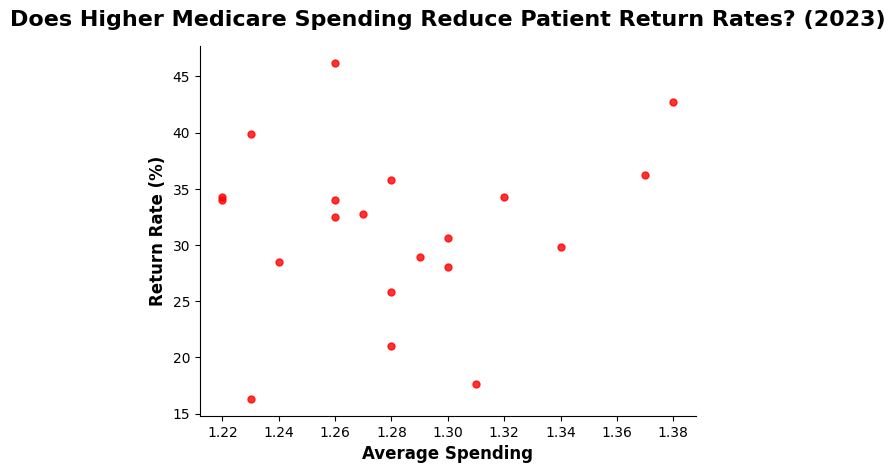

In [ ]:
plt.Figure(figsize=(14,8))
plt.scatter(result5['avg_spending'], result5['return_rate'], 
            color = 'red', 
            alpha=0.8,          # transparency of dots
            s=25,)               #size of dots

#labels
plt.xlabel("Average Spending",
           fontsize=12,
           fontweight= 'bold')
plt.ylabel("Return Rate (%)",
           fontsize=12,
           fontweight= 'bold')
plt.title("Does Higher Medicare Spending Reduce Patient Return Rates? (2023)",
          fontsize=16,
           fontweight='bold',
           pad= 20,
           y=0.98)  #position of title

ax=plt.gca()
ax.spines['top'].set_visible(False) 
ax.spines['right'].set_visible(False) 

plt.show()



##### The scatter plot above shows no strong correlation between Medicare spending and patient return rate. This means that spending more doesn't always reduce patient returns.